# Linear Regression

### Import Libraries

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('linear_reg.csv')
df.head(10)

,x,y
0,0.000000,4875.681920
1,1.004016,3475.944260
2,2.008032,5375.193619
3,3.012048,5696.649452
4,4.016064,4662.372126
5,5.020080,5303.223917
6,6.024096,6026.382338
7,7.028112,3838.603415
8,8.032129,4947.094183
9,9.036145,4970.456372


<Axes: xlabel='x', ylabel='y'>

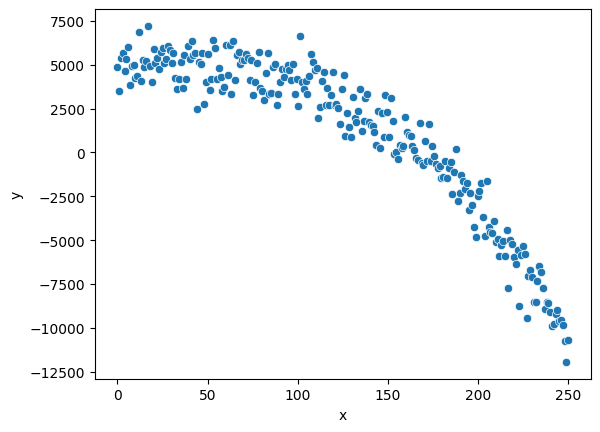

In [3]:
sns.scatterplot(x=df['x'],y=df['y'])

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
X = df[['x']].to_numpy()
X[:10]

array([[0.        ],
       [1.00401606],
       [2.00803213],
       [3.01204819],
       [4.01606426],
       [5.02008032],
       [6.02409639],
       [7.02811245],
       [8.03212851],
       [9.03614458]])

In [6]:
y = df['y'].to_numpy()
y[:10]

array([4875.68192029, 3475.94426027, 5375.19361891, 5696.64945213,
       4662.37212621, 5303.22391661, 6026.38233767, 3838.60341505,
       4947.09418277, 4970.45637166])

In [7]:
reg = LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
reg.coef_

array([-57.81943408])

In [9]:
reg.intercept_

np.float64(8234.159086573562)

The result of the linear regression is the coefficients $\theta$ 's of the equation:
<br><br>
<center>$h(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n $</center>

* `coef_` returns a list of $\theta_1, \theta_2, ... , \theta_n$
* `intercept_` returns the value of $\theta_0$

In the previous example, we only have $x_1$, thus only one coefficient $\theta_1$

To draw the result, we just have to replace the coefficients and intercept in above equation and draw the resulting line

0.8127692919688235


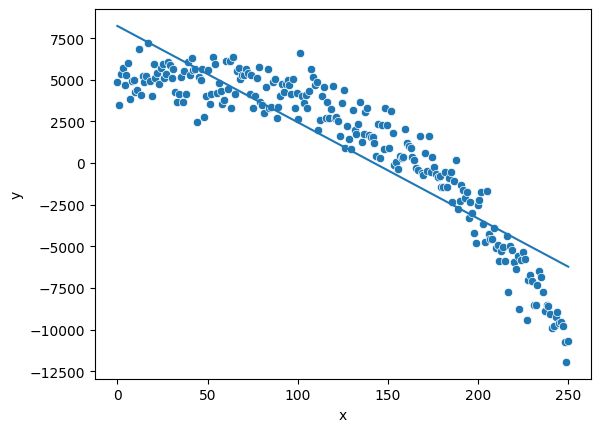

In [10]:
theta0 = reg.intercept_
theta1 = reg.coef_[0]
h = theta0 + theta1 * df['x']
sns.scatterplot(x=df['x'],y=df['y'])
sns.lineplot(x=df['x'],y=h)
r2 = reg.score(X, y)
print(r2)

<b>Note</b>: You can use seaborn's `regplot` function that will fit the Linear Regression then plot both scattered points and linear regression result. As below:

<Axes: >

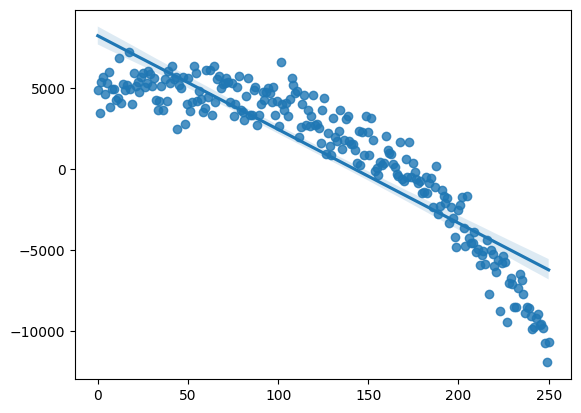

In [11]:
sns.regplot(x=X,y=y)

<hr />

## Linear Regression for a non-linear model

Clearly, above solution is not convenient. The linear model above $h(x) = \theta_0 + \theta_1 x_1$ has a large error, let's measure it:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left(h^{(i)} - y^{(i)}\right)^2
$$

In [12]:
m = y.shape[0]
error = np.sum((h-y)**2)/(2*m) # négyzetes hiba számolása
error

np.float64(2021625.0769523177)

Let's take the following model: $h(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_1^2 + \theta_3 x_1^3$

Then replace the values $x_1^2$ with a new variable called $x_2$, and $x_1^3$ with $x_3$.

The model becomes:
$h(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3$


This can be done easily using pandas by introducing new columns:

In [13]:
df['x2'] = df['x']**2
df['x3'] = df['x']**3
df.head()

,x,y,x2,x3
0,0.000000,4875.681920,0.000000,0.000000
1,1.004016,3475.944260,1.008048,1.012097
2,2.008032,5375.193619,4.032193,8.096773
3,3.012048,5696.649452,9.072434,27.326609
4,4.016064,4662.372126,16.128772,64.774185


In [14]:
X = df[['x','x2','x3']].to_numpy()
y = df['y'].to_numpy()

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False) # alternatív megoldás
X = poly.fit_transform(df[['x']])

In [16]:
reg2 = LinearRegression()
reg2.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
reg2.coef_

array([ 2.50798685e+00, -4.30449638e-02, -8.80001639e-04])

In [18]:
reg2.intercept_

np.float64(5043.113943114056)

So the final solution is:

$h(x) = 5043 + 2.507 x_1 -0.043 x_2 - 0.00088 x_3$

which is equivalent to:

$h(x) = 5043 + 2.507 x_1 -0.043 x_1^2 - 0.00088 x_1^3$

Let's draw the result:

<Axes: xlabel='x', ylabel='y'>

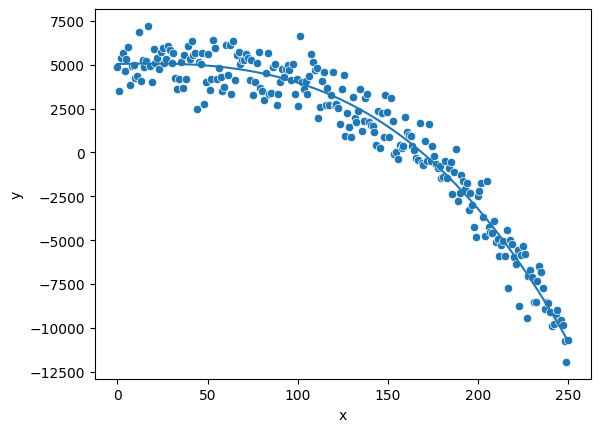

In [19]:
theta0 = reg2.intercept_
theta1 = reg2.coef_[0]
theta2 = reg2.coef_[1]
theta3 = reg2.coef_[2]
h = theta0 + theta1 * df['x'] + theta2 * df['x2'] + theta3 * df['x3'] # prediktált érték
sns.scatterplot(x=df['x'],y=df['y'])
sns.lineplot(x=df['x'],y=h)

<Axes: xlabel='x', ylabel='y'>

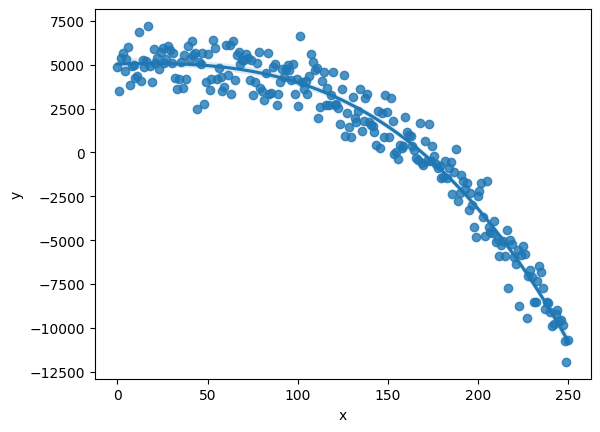

In [20]:
sns.regplot(x='x', y='y', data=df, order=3) # alternatív megoldás

Clearly, above line fits the dataset better. And cost is:

In [21]:
m = y.shape[0]
error2 = np.sum((h-y)**2)/(2*m)
error2

np.float64(452753.5284911734)

In [22]:
error/error2

np.float64(4.465177960488783)

Solution improved 4.5 times with the new model

### How to predict new values?

if you have a value of $x$, you can either replace the value in previous $h(x)$ equation, or use `predict` function below:

In [23]:
reg2.predict([[55,55**2,55**3]])

array([4904.43193151])

In [24]:
from mpl_toolkits.mplot3d import Axes3D


np.random.seed(42)
n_samples = 100

x1 = np.linspace(-5, 5, n_samples) + np.random.normal(0, 0.5, n_samples)
x2 = np.linspace(-5, 5, n_samples) + np.random.normal(0, 0.5, n_samples)
x3 = np.linspace(-5, 5, n_samples) + np.random.normal(0, 0.5, n_samples)

y = 1.5*x1 - 2*x2 + 0.5*x3 + np.random.normal(0, 1.0, n_samples)

# DataFrame
df = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3, 'y': y})

In [25]:
X = df[['x1', 'x2', 'x3']]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 1.29058654 -1.92628582  0.63316898]
Intercept: 0.09082352528818742


C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


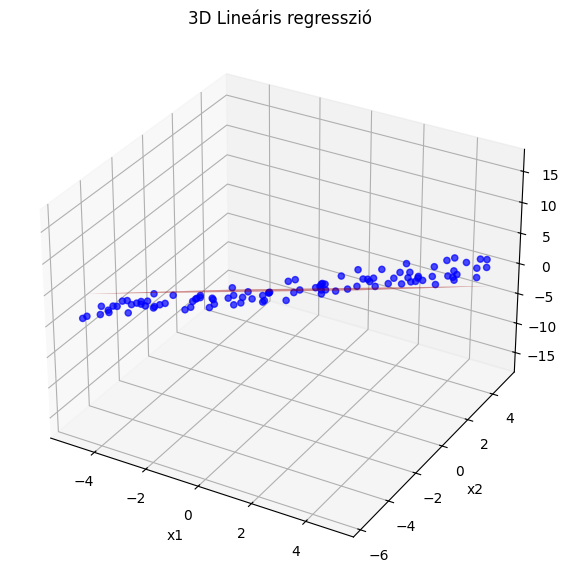

In [26]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(df['x1'], df['x2'], y, c='blue', label='Adatok', alpha=0.7)

grid_size = 20
x1_grid, x2_grid = np.meshgrid(np.linspace(-5,5,grid_size), np.linspace(-5,5,grid_size))
x3_fixed = 0
X_grid = np.column_stack([x1_grid.ravel(), x2_grid.ravel(), np.full_like(x1_grid.ravel(), x3_fixed)])
y_grid = model.predict(X_grid).reshape(x1_grid.shape)

# Surface plot
ax.plot_surface(x1_grid, x2_grid, y_grid, color='red', alpha=0.5)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Lineáris regresszió')
plt.show()

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(df['y'], y_pred)
print("R^2 score:", r2)

R^2 score: 0.6690012044403177
